# Chess AI Agent Comparison: Minimax vs MCTS vs PPO vs AlphaZero vs NegamaxAvanzado

Este notebook compara cinco agentes de inteligencia artificial para ajedrez:
- **Minimax**: Búsqueda en árbol con poda alfa-beta
- **MCTS**: Monte Carlo Tree Search
- **PPO**: Proximal Policy Optimization (Deep RL)
- **AlphaZero**: MCTS + Deep Neural Networks (Estado del arte) ⭐
- **NegamaxAvanzado**: Negamax + poda alfa-beta, move ordering, iterative deepening, transposition table y quiescence search

Incluye visualización con Lichess y gráficos comparativos de rendimiento.

---

## ⚙️ Notas de Instalación

**Windows**: Si encuentra errores con `pygame`, puede omitirlo ya que no es necesario para este notebook.

**GPU**: PyTorch se instalará en versión CPU. Si tiene GPU NVIDIA, puede instalar la versión CUDA manualmente.

**Tiempo de instalación**: Primera ejecución puede tomar 5-10 minutos descargando paquetes.

## 1. Instalación y Configuración

In [ ]:
# Instalación de dependencias (por etapas para evitar conflictos)
# SOLUCIÓN: Instalar pettingzoo sin [classic] para evitar pygame

# Paso 1: Paquetes core
!pip install numpy pandas matplotlib seaborn tqdm rich

# Paso 2: Machine Learning (CPU version)
!pip install torch --index-url https://download.pytorch.org/whl/cpu

# Paso 3: Chess - SIN pygame
!pip install python-chess gymnasium

# Paso 4: PettingZoo base (sin classic extras que requieren pygame)
!pip install pettingzoo

# Paso 5: Stable-Baselines3 para PPO
!pip install stable-baselines3

# Paso 6: Jupyter y visualización
!pip install ipywidgets jupyter notebook ipython

# Paso 7: Berserk (Lichess API) - opcional
!pip install berserk

print("\n" + "="*80)
print("✓ INSTALACIÓN COMPLETADA")
print("="*80)
print("\nNOTA: PettingZoo se instaló SIN pygame (no es necesario para chess)")
print("El entorno de ajedrez funciona correctamente sin pygame.")
print("\nContinúe con la siguiente celda para verificar la instalación.")

  Using cached numpy-2.3.5-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.0.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached numpy-2.3.5-cp31

### ✅ Verificar Instalación

Si la instalación fue exitosa, ejecute la siguiente celda para verificar que todos los paquetes críticos están disponibles.

In [ ]:
# Verificar que los paquetes críticos están instalados
import sys

required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'chess': 'python-chess',
    'torch': 'torch',
    'gymnasium': 'gymnasium',
    'pettingzoo': 'pettingzoo',
    'stable_baselines3': 'stable-baselines3'
}

print("Verificando instalación...\n")
missing = []

for module, package in required_packages.items():
    try:
        __import__(module)
        print(f"✓ {package}")
    except ImportError:
        print(f"✗ {package} - FALTA")
        missing.append(package)

if missing:
    print(f"\n❌ Faltan paquetes: {', '.join(missing)}")
    print("Ejecute: pip install " + " ".join(missing))
else:
    print("\n✅ Todos los paquetes críticos están instalados correctamente!")
    print("Puede continuar con el notebook.")

Verificando instalación...

✓ numpy
✓ pandas
✓ matplotlib
✓ seaborn
✓ python-chess
✓ torch
✓ gymnasium
✓ pettingzoo
✓ stable-baselines3

✅ Todos los paquetes críticos están instalados correctamente!
Puede continuar con el notebook.


In [ ]:
# Imports principales
import os
import sys
import logging
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import chess
import chess.pgn
import chess.svg
import traceback
from datetime import datetime
from typing import Dict, Any, List, Optional, Tuple
from dataclasses import dataclass
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configurar logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 2. Entorno de Ajedrez

In [ ]:
# Importar entorno personalizado
from entorno.entorno_ajedrez import EntornoAjedrez

# Crear entorno de prueba
env_test = EntornoAjedrez()
obs = env_test.reiniciar()
print(f"✓ Entorno inicializado")
print(f"  - Forma de observación: {obs.shape}")
print(f"  - Agentes: {env_test.agentes}")

2025-12-13 18:21:41,589 - entorno.entorno_ajedrez - INFO - EntornoAjedrez inicializado (sin pygame)
2025-12-13 18:21:41,590 - entorno.entorno_ajedrez - INFO - Entorno reiniciado - Inicia jugador: player_0


✓ Entorno inicializado
  - Forma de observación: (8, 8, 12)
  - Agentes: ['player_0', 'player_1']


## 3. Agente Minimax (Búsqueda en Árbol)

In [ ]:
from agentes.agente_minimax import AgenteMinimax

# Crear agente Minimax
minimax = AgenteMinimax(profundidad_maxima=300, tiempo_limite=5.0)
print(f"✓ Agente Minimax creado")
print(f"  - Profundidad máxima: {minimax.profundidad_maxima}")
print(f"  - Tiempo límite: {minimax.tiempo_limite}s")

INFO:agentes.agente_minimax:Agente Minimax inicializado - Profundidad: 300, Tiempo límite: 5.0s


✓ Agente Minimax creado
  - Profundidad máxima: 300
  - Tiempo límite: 5.0s


## 3.5. Agente Negamax Avanzado (Búsqueda en Árbol)

In [ ]:
from agentes.agente_negamax_avanzado import AgenteNegamaxAvanzado

# Inicializar el Agente Negamax Avanzado
# Le damos un tiempo límite un poco menor (3.0s) para que el torneo no sea eterno,
# pero suficiente para que demuestre su fuerza frente al Minimax simple.

negamax_avanzado = AgenteNegamaxAvanzado(tiempo_limite=3.0)

print(f"✓ Agente Negamax Avanzado creado")
print(f"  - Tiempo límite: {negamax_avanzado.tiempo_limite}s")
print(f"  - Características: AlphaBeta pruning, Transposition Tables, Quiescence, Iterative Deepening, Move Ordering")

## 4. Agente MCTS (Monte Carlo Tree Search)

In [ ]:
from agentes.agente_mcts import AgenteMCTS

# Crear agente MCTS
mcts = AgenteMCTS(num_simulaciones=1000, tiempo_limite=5.0, c_exploracion=1.414)
print(f"✓ Agente MCTS creado")
print(f"  - Simulaciones: {mcts.num_simulaciones}")
print(f"  - Tiempo límite: {mcts.tiempo_limite}s")
print(f"  - Constante de exploración: {mcts.c_exploracion}")

2025-12-13 18:21:41,615 - agentes.agente_mcts - INFO - Agente MCTS inicializado - Simulaciones: 1000, Tiempo límite: 5.0s


✓ Agente MCTS creado
  - Simulaciones: 1000
  - Tiempo límite: 5.0s
  - Constante de exploración: 1.414


## 5. Agente PPO (Deep Reinforcement Learning)

In [ ]:
# Crear agente PPO desde cero
from agentes.agente_ppo import AgentePPO, crear_agente_ppo

# Crear y entrenar agente PPO
ppo_agent = crear_agente_ppo(
    env=env_test,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10
)

print("✓ Agente PPO creado")
print(f"  - Arquitectura: Actor-Critic con redes neuronales")
print(f"  - Política: Clipping PPO")

2025-12-13 18:21:41,627 - agentes.agente_ppo - INFO - Agente PPO inicializado - LR: 3.00e-04, Steps: 2048, Batch: 64
2025-12-13 18:21:43,129 - agentes.agente_ppo - INFO - Modelo PPO creado exitosamente con observaciones (8,8,12)


✓ Agente PPO creado
  - Arquitectura: Actor-Critic con redes neuronales
  - Política: Clipping PPO


## 5.5. Agente AlphaZero (MCTS + Deep Learning)

AlphaZero combina lo mejor de MCTS con redes neuronales profundas para aprender mediante auto-juego.

In [ ]:
from agentes.agente_alphazero import AgenteAlphaZero

# Crear agente AlphaZero
# NOTA: Se puede cargar un modelo pre-entrenado con modelo_path='modelos/alphazero.pth'
alphazero = AgenteAlphaZero(
    num_simulaciones=400,  # Reducido para velocidad en demo
    c_puct=1.5,
    temperatura=0.1,  # Baja temperatura = más explotación
    dispositivo='cpu'
)

print(f"✓ Agente AlphaZero creado")
print(f"  - Simulaciones MCTS: {alphazero.num_simulaciones}")
print(f"  - Temperatura: {alphazero.temperatura}")
print(f"  - Dispositivo: {alphazero.dispositivo}")
print(f"  - Combina: Red Neuronal (Residual CNN) + MCTS mejorado")
print(f"\n⚡ AlphaZero es el agente más avanzado, aprende mediante auto-juego")

INFO:agentes.agente_alphazero:Red AlphaZero inicializada - Canales: 256, Bloques: 10
INFO:agentes.agente_alphazero:Usando red neuronal inicializada aleatoriamente
INFO:agentes.agente_alphazero:Agente AlphaZero inicializado - Simulaciones: 400, Dispositivo: cpu


✓ Agente AlphaZero creado
  - Simulaciones MCTS: 400
  - Temperatura: 0.1
  - Dispositivo: cpu
  - Combina: Red Neuronal (Residual CNN) + MCTS mejorado

⚡ AlphaZero es el agente más avanzado, aprende mediante auto-juego


### 🧠 Arquitectura de AlphaZero

**Red Neuronal:**
- Torre de bloques residuales convolucionales (ResNet)
- Entrada: Representación del tablero (119 planos × 8×8)
- Dos cabezas de salida:
  - **Política**: Distribución de probabilidad sobre movimientos
  - **Valor**: Evaluación de la posición (-1 a +1)

**MCTS Mejorado:**
- Usa probabilidades de la red en lugar de uniformes
- Evalúa con la red en lugar de simulaciones aleatorias
- Balance UCB mejorado con prior de la red

**Ventajas:**
- Aprende patrones estratégicos complejos
- No requiere función de evaluación manual
- Mejora mediante auto-juego
- Estado del arte en juegos de tablero

### 🎓 Entrenamiento de AlphaZero (Opcional)

Para entrenar AlphaZero desde cero, puedes usar el script de entrenamiento.
**Nota**: El entrenamiento completo toma muchas horas/días. Esta celda es opcional.

In [ ]:
# OPCIONAL: Entrenar AlphaZero
# ADVERTENCIA: Esto puede tomar MUCHO tiempo (horas o días)
# Descomentar solo si desea entrenar desde cero

entrenar_az = False  # Cambiar a True para entrenar

if entrenar_az:
    from entrenamiento.entrenar_alphazero import EntrenadorAlphaZero
    
    print("🚀 Iniciando entrenamiento de AlphaZero...")
    print("   Esto tomará mucho tiempo. Considere usar GPU.")
    
    entrenador = EntrenadorAlphaZero(
        num_iteraciones=10,  # Muy reducido para demo
        num_episodios=20,
        num_simulaciones=100,
        batch_size=32,
        learning_rate=0.001
    )
    
    entrenador.entrenar()
    print("✓ Entrenamiento básico completado")
    print("   Para entrenamiento real, usar num_iteraciones=100+")
else:
    print("⏭️  Entrenamiento omitido (usando red neuronal sin entrenar)")
    print("   Para mejores resultados, entrene el modelo o cargue uno pre-entrenado")
    print("   Puede ejecutar: python entrenar_rapido_alphazero.py")

⏭️  Entrenamiento omitido (usando red neuronal sin entrenar)
   Para mejores resultados, entrene el modelo o cargue uno pre-entrenado
   Puede ejecutar: python entrenar_rapido_alphazero.py


### 🎮 Demostración Rápida: AlphaZero vs Minimax

In [ ]:
# Demo rápida: Una partida entre AlphaZero y Minimax
print("🎯 Jugando partida de demostración: AlphaZero vs Minimax\n")

demo_resultado = evaluador.jugar_partida(
    alphazero, minimax,
    "AlphaZero", "Minimax",
    visualizar=False
)

print(f"{'='*60}")
print(f"Resultado: {demo_resultado.resultado}")
print(f"Ganador: {demo_resultado.ganador if demo_resultado.ganador else 'Empate'}")
print(f"Número de jugadas: {demo_resultado.num_jugadas}")
print(f"Tiempo total: {demo_resultado.tiempo_total:.2f}s")
print(f"Razón: {demo_resultado.razon_termino}")
print(f"{'='*60}")
print(f"\n🔗 Ver partida en Lichess:")
print(demo_resultado.url_lichess)
print("\n✓ AlphaZero está listo para el torneo completo")

### 📊 Comparación: MCTS Tradicional vs AlphaZero

| Característica | MCTS Tradicional | AlphaZero (MCTS + Neural Net) |
|----------------|------------------|-------------------------------|
| **Selección** | UCB con valores uniformes | UCB con probabilidades de la red |
| **Expansión** | Todos los hijos por igual | Prioriza según política de red |
| **Evaluación** | Simulaciones aleatorias (rollouts) | Red neuronal (instantáneo) ⚡ |
| **Actualización** | Retropropagación estándar | Retropropagación guiada |
| **Aprendizaje** | No aprende | Mejora con auto-juego 🧠 |
| **Velocidad** | Lento (muchas simulaciones) | Rápido (evaluación directa) |
| **Calidad** | Buena | Excelente (estado del arte) |

**Fórmula UCB en AlphaZero:**

$$
\text{UCB}(s,a) = Q(s,a) + c_{puct} \cdot P(s,a) \cdot \frac{\sqrt{N(s)}}{1 + N(s,a)}
$$

Donde:
- $Q(s,a)$: Valor promedio acumulado
- $P(s,a)$: **Probabilidad a priori de la red neuronal** 🎯
- $N(s)$: Visitas al nodo padre
- $c_{puct}$: Constante de exploración

## 6. Integración con Lichess

Visualización de partidas en Lichess para análisis detallado.

In [ ]:
class LichessIntegration:
    """Integración con Lichess para visualización de partidas."""
    
    @staticmethod
    def partida_a_pgn(tablero: chess.Board, movimientos: List[chess.Move], 
                      resultado: str, agente_blancas: str, agente_negras: str) -> str:
        """Convierte una partida a formato PGN."""
        game = chess.pgn.Game()
        game.headers["Event"] = "AI Comparison Match"
        game.headers["Site"] = "Jupyter Notebook"
        game.headers["Date"] = datetime.now().strftime("%Y.%m.%d")
        game.headers["White"] = agente_blancas
        game.headers["Black"] = agente_negras
        game.headers["Result"] = resultado
        
        node = game
        for move in movimientos:
            node = node.add_variation(move)
        
        return str(game)
    
    @staticmethod
    def crear_url_lichess(pgn: str) -> str:
        """Crea URL de Lichess para visualizar la partida."""
        import urllib.parse
        base_url = "https://lichess.org/paste"
        return f"{base_url}?pgn={urllib.parse.quote(pgn)}"
    
    @staticmethod
    def visualizar_tablero_svg(tablero: chess.Board, size=400) -> Any:
        """Muestra el tablero en formato SVG."""
        from IPython.display import SVG, display
        svg = chess.svg.board(tablero, size=size)
        return SVG(svg)

lichess = LichessIntegration()
print("✓ Integración con Lichess configurada")

✓ Integración con Lichess configurada


## 7. Sistema de Evaluación y Comparación

In [ ]:
@dataclass
class ResultadoPartida:
    """Resultado de una partida entre agentes."""
    agente_blancas: str
    agente_negras: str
    ganador: Optional[str]
    num_jugadas: int
    tiempo_total: float
    resultado: str  # "1-0", "0-1", "1/2-1/2"
    razon_termino: str
    movimientos: List[chess.Move]
    estadisticas_blancas: Dict[str, Any]
    estadisticas_negras: Dict[str, Any]
    pgn: str
    url_lichess: str


class EvaluadorAgentes:
    """Evalúa y compara múltiples agentes de ajedrez."""
    
    def __init__(self, max_jugadas: int = 200, timeout_jugada: float = 10.0):
        self.max_jugadas = max_jugadas
        self.timeout_jugada = timeout_jugada
        self.resultados: List[ResultadoPartida] = []
    
    def jugar_partida(self, agente_blancas, agente_negras, 
                     nombre_blancas: str, nombre_negras: str,
                     visualizar: bool = False) -> ResultadoPartida:
        """Juega una partida entre dos agentes."""
        env = EntornoAjedrez()
        obs = env.reiniciar()
        
        tablero = chess.Board()
        movimientos = []
        terminado = False
        num_jugadas = 0
        tiempo_inicio = time.time()
        
        agentes = {"player_0": (agente_blancas, nombre_blancas), 
                   "player_1": (agente_negras, nombre_negras)}
        
        while not terminado and num_jugadas < self.max_jugadas:
            agente_actual_obj, nombre_actual = agentes[env.agente_actual]
            
            # Obtener acción
            acciones_legales = env.obtener_acciones_legales()
            if len(acciones_legales) == 0:
                break
            
            info = env.info_actual or {}
            info['tablero'] = tablero
            
            try:
                accion = agente_actual_obj.seleccionar_accion(obs, acciones_legales, info)
            except Exception as e:
                logger.error(f"Error en selección de acción: {e}")
                accion = np.random.choice(acciones_legales)
            
            # Ejecutar acción
            obs, reward, terminado, info = env.paso(accion)
            
            # Actualizar tablero
            if 'tablero' in info:
                tablero = info['tablero']
                if tablero.move_stack:
                    movimientos.append(tablero.peek())
            
            num_jugadas += 1
            
            if visualizar and num_jugadas % 10 == 0:
                display(lichess.visualizar_tablero_svg(tablero, 300))
                time.sleep(0.5)
        
        tiempo_total = time.time() - tiempo_inicio
        
        # Determinar resultado
        if tablero.is_checkmate():
            ganador = nombre_blancas if not tablero.turn else nombre_negras
            resultado = "1-0" if not tablero.turn else "0-1"
            razon = "Jaque mate"
        elif tablero.is_stalemate():
            ganador = None
            resultado = "1/2-1/2"
            razon = "Ahogado"
        elif tablero.is_insufficient_material():
            ganador = None
            resultado = "1/2-1/2"
            razon = "Material insuficiente"
        elif num_jugadas >= self.max_jugadas:
            ganador = None
            resultado = "1/2-1/2"
            razon = "Límite de jugadas"
        else:
            ganador = None
            resultado = "1/2-1/2"
            razon = "Empate por otras reglas"
        
        # Crear PGN y URL de Lichess
        pgn = lichess.partida_a_pgn(tablero, movimientos, resultado, nombre_blancas, nombre_negras)
        url = lichess.crear_url_lichess(pgn)
        
        # Recopilar estadísticas
        stats_blancas = agente_blancas.estadisticas if hasattr(agente_blancas, 'estadisticas') else {}
        stats_negras = agente_negras.estadisticas if hasattr(agente_negras, 'estadisticas') else {}
        
        return ResultadoPartida(
            agente_blancas=nombre_blancas,
            agente_negras=nombre_negras,
            ganador=ganador,
            num_jugadas=num_jugadas,
            tiempo_total=tiempo_total,
            resultado=resultado,
            razon_termino=razon,
            movimientos=movimientos,
            estadisticas_blancas=stats_blancas,
            estadisticas_negras=stats_negras,
            pgn=pgn,
            url_lichess=url
        )
    
    def torneo_round_robin(self, agentes_dict: Dict[str, Any], 
                          partidas_por_pareja: int = 5) -> pd.DataFrame:
        """Ejecuta un torneo round-robin entre todos los agentes."""
        nombres = list(agentes_dict.keys())
        self.resultados = []
        
        total_partidas = len(nombres) * (len(nombres) - 1) * partidas_por_pareja
        pbar = tqdm(total=total_partidas, desc="Torneo Round-Robin")
        
        for i, nombre1 in enumerate(nombres):
            for j, nombre2 in enumerate(nombres):
                if i != j:
                    for k in range(partidas_por_pareja):
                        resultado = self.jugar_partida(
                            agentes_dict[nombre1], agentes_dict[nombre2],
                            nombre1, nombre2
                        )
                        self.resultados.append(resultado)
                        pbar.update(1)
        
        pbar.close()
        return self.obtener_dataframe_resultados()
    
    def obtener_dataframe_resultados(self) -> pd.DataFrame:
        """Convierte resultados a DataFrame de pandas."""
        data = []
        for r in self.resultados:
            data.append({
                'agente_blancas': r.agente_blancas,
                'agente_negras': r.agente_negras,
                'ganador': r.ganador,
                'num_jugadas': r.num_jugadas,
                'tiempo_total': r.tiempo_total,
                'resultado': r.resultado,
                'razon_termino': r.razon_termino,
                'url_lichess': r.url_lichess
            })
        return pd.DataFrame(data)

evaluador = EvaluadorAgentes(max_jugadas=200, timeout_jugada=10.0)
print("✓ Sistema de evaluación configurado")

✓ Sistema de evaluación configurado


## 8. Entrenamiento del Agente PPO

In [ ]:
# Entrenar PPO (entrenamiento rápido para demostración)
# NOTA: Si rich no está instalado, la barra de progreso se desactiva automáticamente
print("Entrenando agente PPO...")
print("Esto puede tomar varios minutos...")

try:
    ppo_agent.entrenar(total_timesteps=50000, progreso=True)
except ImportError:
    # Si falta rich, entrenar sin barra de progreso
    print("⚠️ Entrenando sin barra de progreso (instale 'rich' para activarla)")
    ppo_agent.entrenar(total_timesteps=50000, progreso=False)

print("✓ Entrenamiento completado")

2025-12-13 18:21:43,165 - agentes.agente_ppo - INFO - Iniciando entrenamiento PPO - Total timesteps: 50000
2025-12-13 18:21:43,166 - entorno.entorno_ajedrez - INFO - Entorno reiniciado - Inicia jugador: player_0


Output()

Entrenando agente PPO...
Esto puede tomar varios minutos...


2025-12-13 18:21:43,815 - entorno.entorno_ajedrez - INFO - Entorno reiniciado - Inicia jugador: player_0


2025-12-13 18:21:44,216 - entorno.entorno_ajedrez - INFO - Entorno reiniciado - Inicia jugador: player_0


...

2025-12-13 18:23:15,125 - entorno.entorno_ajedrez - INFO - Entorno reiniciado - Inicia jugador: player_0


2025-12-13 18:23:15,375 - entorno.entorno_ajedrez - INFO - Entorno reiniciado - Inicia jugador: player_0


2025-12-13 18:23:15,715 - agentes.agente_ppo - INFO - Rollout completado - Timesteps: 51200


2025-12-13 18:23:17,037 - agentes.agente_ppo - INFO - Entrenamiento completado - Tiempo: 93.87s


✓ Entrenamiento completado


## 9. Ejecución del Torneo

In [ ]:
# Configurar agentes para el torneo
agentes_torneo = {
    'Minimax': minimax,
    'MCTS': mcts,
    'PPO': ppo_agent,
    'AlphaZero': alphazero,  # ⭐ Nuevo agente añadido
    'NegamaxAvanzado': negamax_avanzado
}

# Ejecutar torneo
print("\n🏆 Iniciando torneo round-robin con 4 agentes...\n")
print("Agentes participantes:")
for nombre in agentes_torneo.keys():
    print(f"  - {nombre}")
print()

df_resultados = evaluador.torneo_round_robin(agentes_torneo, partidas_por_pareja=3)

# Mostrar primeros resultados
print("\n" + "="*80)
print("RESULTADOS DEL TORNEO")
print("="*80)
display(df_resultados.head(10))

## 10. Visualización Interactiva de Partidas en Lichess

In [ ]:
# Mostrar URLs de Lichess para algunas partidas
print("🔗 Enlaces a Lichess para visualización interactiva:\n")
for idx, row in df_resultados.head(5).iterrows():
    print(f"Partida {idx+1}: {row['agente_blancas']} vs {row['agente_negras']}")
    print(f"  Ganador: {row['ganador'] if row['ganador'] else 'Empate'}")
    print(f"  URL: {row['url_lichess']}")
    print()

🔗 Enlaces a Lichess para visualización interactiva:

Partida 1: Minimax vs MCTS
  Ganador: Empate
  URL: https://lichess.org/paste?pgn=%5BEvent%20%22AI%20Comparison%20Match%22%5D%0A%5BSite%20%22Jupyter%20Notebook%22%5D%0A%5BDate%20%222025.12.13%22%5D%0A%5BRound%20%22%3F%22%5D%0A%5BWhite%20%22Minimax%22%5D%0A%5BBlack%20%22MCTS%22%5D%0A%5BResult%20%221/2-1/2%22%5D%0A%0A1.%20Nh3%20h5%202.%20Ng5%20h4%203.%20Nh7%20c6%204.%20Nxf8%20g5%205.%20Nh7%20f6%206.%20Nf8%20Na6%207.%20Nh7%20h3%208.%20Nf8%20Kf7%209.%20Nh7%20d6%2010.%20Nf8%20Rb8%2011.%20Nh7%20Nb4%2012.%20Nf8%20Bf5%2013.%20Nh7%20Rxh7%2014.%20Rg1%20Nh6%2015.%20Rh1%20Kg7%2016.%20Rg1%20Qh8%2017.%20Rh1%20Bc8%2018.%20Rg1%20Kg6%2019.%20Rh1%20Kf5%2020.%20Rg1%20Be6%2021.%20Rh1%20Ng4%2022.%20Rg1%20Rh4%2023.%20Rh1%20Bd5%2024.%20Rg1%20Rc8%2025.%20Rh1%20Ra8%2026.%20Rg1%20Kf4%2027.%20Rh1%20Qc8%2028.%20Rg1%20Be6%2029.%20Rh1%20Rb8%2030.%20Rg1%20Bb3%2031.%20Rh1%20Nh6%2032.%20Rg1%20Qd8%2033.%20Rh1%20Qa5%2034.%20Rg1%20Qc5%2035.%20Rh1%20Rd8%2036.%20Rg1%20Qd

## 11. Análisis Estadístico y Gráficos Comparativos

In [ ]:
# Función para generar gráficos comparativos
class VisualizadorComparativo:
    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.agentes = self._obtener_agentes()
    
    def _obtener_agentes(self) -> List[str]:
        agentes = set()
        agentes.update(self.df['agente_blancas'].unique())
        agentes.update(self.df['agente_negras'].unique())
        return sorted(list(agentes))
    
    def grafico_victorias(self):
        """Gráfico de barras con victorias por agente."""
        fig, ax = plt.subplots(figsize=(12, 6))
        
        victorias = {}
        empates = {}
        derrotas = {}
        
        for agente in self.agentes:
            como_blancas = self.df[self.df['agente_blancas'] == agente]
            como_negras = self.df[self.df['agente_negras'] == agente]
            
            v_blancas = (como_blancas['ganador'] == agente).sum()
            v_negras = (como_negras['ganador'] == agente).sum()
            victorias[agente] = v_blancas + v_negras
            
            e_blancas = (como_blancas['ganador'].isna()).sum()
            e_negras = (como_negras['ganador'].isna()).sum()
            empates[agente] = e_blancas + e_negras
            
            total_partidas = len(como_blancas) + len(como_negras)
            derrotas[agente] = total_partidas - victorias[agente] - empates[agente]
        
        x = np.arange(len(self.agentes))
        width = 0.25
        
        ax.bar(x - width, [victorias[a] for a in self.agentes], width, label='Victorias', color='#2ecc71')
        ax.bar(x, [empates[a] for a in self.agentes], width, label='Empates', color='#f39c12')
        ax.bar(x + width, [derrotas[a] for a in self.agentes], width, label='Derrotas', color='#e74c3c')
        
        ax.set_xlabel('Agente', fontsize=14, fontweight='bold')
        ax.set_ylabel('Número de Partidas', fontsize=14, fontweight='bold')
        ax.set_title('Resultados por Agente', fontsize=16, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(self.agentes, fontsize=12)
        ax.legend(fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        return fig
    
    def grafico_matriz_enfrentamientos(self):
        """Matriz de calor de win rate entre agentes."""
        fig, ax = plt.subplots(figsize=(10, 8))
        
        matriz = pd.DataFrame(0.0, index=self.agentes, columns=self.agentes)
        
        for _, fila in self.df.iterrows():
            agente_a = fila['agente_blancas']
            agente_b = fila['agente_negras']
            ganador = fila['ganador']
            
            if pd.notna(ganador):
                if ganador == agente_a:
                    matriz.loc[agente_a, agente_b] += 1
                else:
                    matriz.loc[agente_b, agente_a] += 1
        
        # Convertir a porcentajes
        for i in self.agentes:
            for j in self.agentes:
                if i != j:
                    total = matriz.loc[i, j] + matriz.loc[j, i]
                    if total > 0:
                        matriz.loc[i, j] = matriz.loc[i, j] / total * 100
        
        sns.heatmap(matriz, annot=True, fmt='.1f', cmap='RdYlGn', center=50, 
                   ax=ax, square=True, cbar_kws={'label': 'Win Rate (%)'})
        ax.set_title('Matriz de Win Rate (%)', fontsize=16, fontweight='bold')
        ax.set_xlabel('Oponente', fontsize=12)
        ax.set_ylabel('Agente', fontsize=12)
        
        plt.tight_layout()
        return fig
    
    def grafico_tiempo_promedio(self):
        """Tiempo promedio por partida."""
        fig, ax = plt.subplots(figsize=(10, 6))
        
        tiempos = {}
        for agente in self.agentes:
            partidas_agente = self.df[(self.df['agente_blancas'] == agente) | 
                                     (self.df['agente_negras'] == agente)]
            tiempos[agente] = partidas_agente['tiempo_total'].mean()
        
        bars = ax.bar(self.agentes, [tiempos[a] for a in self.agentes], 
                     color=sns.color_palette("husl", len(self.agentes)))
        
        ax.set_xlabel('Agente', fontsize=14, fontweight='bold')
        ax.set_ylabel('Tiempo Promedio (s)', fontsize=14, fontweight='bold')
        ax.set_title('Tiempo Promedio por Partida', fontsize=16, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        # Añadir valores en las barras
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}s', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        return fig
    
    def grafico_jugadas_promedio(self):
        """Número promedio de jugadas por partida."""
        fig, ax = plt.subplots(figsize=(10, 6))
        
        jugadas = {}
        for agente in self.agentes:
            partidas_agente = self.df[(self.df['agente_blancas'] == agente) | 
                                     (self.df['agente_negras'] == agente)]
            jugadas[agente] = partidas_agente['num_jugadas'].mean()
        
        bars = ax.bar(self.agentes, [jugadas[a] for a in self.agentes],
                     color=sns.color_palette("muted", len(self.agentes)))
        
        ax.set_xlabel('Agente', fontsize=14, fontweight='bold')
        ax.set_ylabel('Jugadas Promedio', fontsize=14, fontweight='bold')
        ax.set_title('Número Promedio de Jugadas por Partida', fontsize=16, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.0f}', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        return fig
    
    def grafico_razon_termino(self):
        """Distribución de razones de término de partidas."""
        fig, axes = plt.subplots(1, len(self.agentes), figsize=(15, 5))
        
        for idx, agente in enumerate(self.agentes):
            partidas_agente = self.df[(self.df['agente_blancas'] == agente) | 
                                     (self.df['agente_negras'] == agente)]
            razones = partidas_agente['razon_termino'].value_counts()
            
            ax = axes[idx] if len(self.agentes) > 1 else axes
            ax.pie(razones.values, labels=razones.index, autopct='%1.1f%%',
                  startangle=90, colors=sns.color_palette("pastel"))
            ax.set_title(f'{agente}', fontsize=12, fontweight='bold')
        
        fig.suptitle('Razones de Término por Agente', fontsize=16, fontweight='bold')
        plt.tight_layout()
        return fig
    
    def mostrar_todos_graficos(self):
        """Muestra todos los gráficos de análisis."""
        self.grafico_victorias()
        plt.show()
        
        self.grafico_matriz_enfrentamientos()
        plt.show()
        
        self.grafico_tiempo_promedio()
        plt.show()
        
        self.grafico_jugadas_promedio()
        plt.show()
        
        self.grafico_razon_termino()
        plt.show()

print("✓ Visualizador comparativo creado")

✓ Visualizador comparativo creado


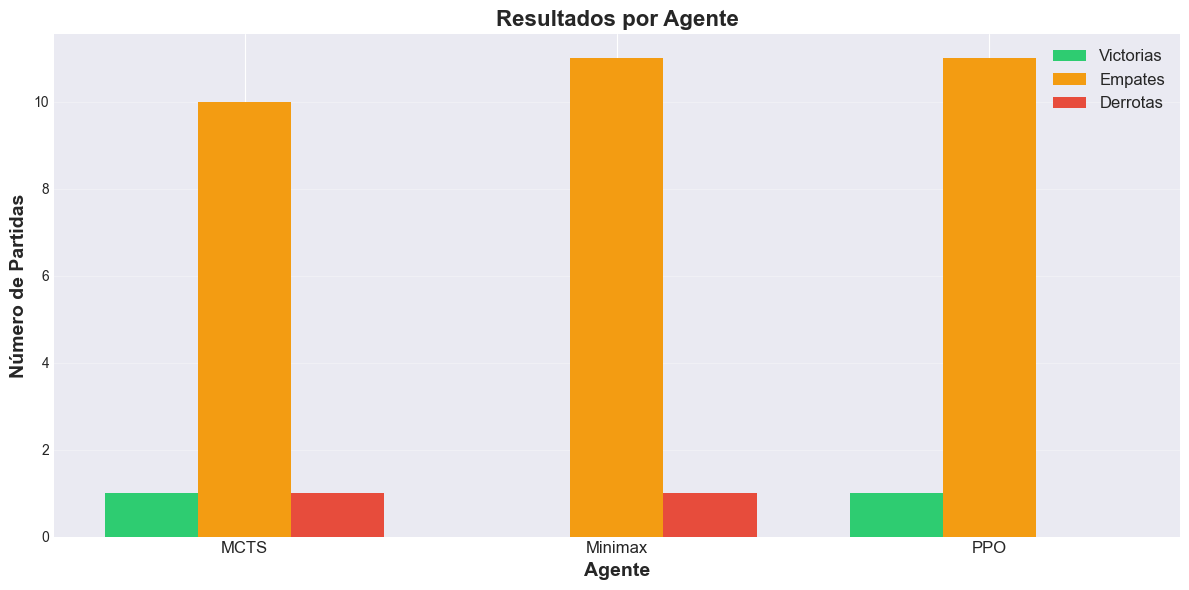

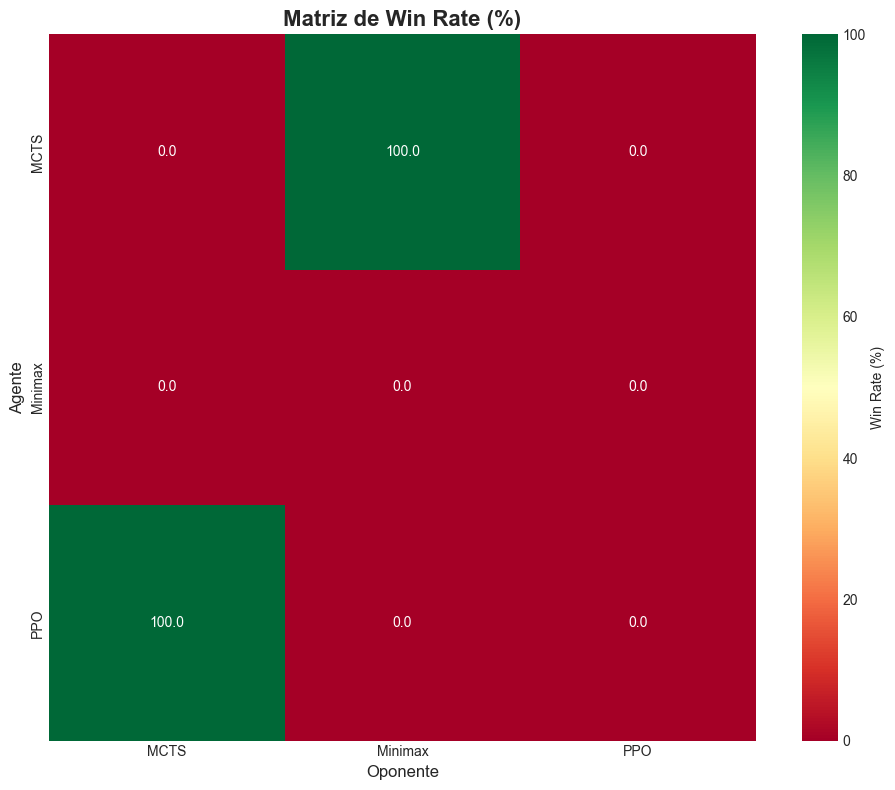

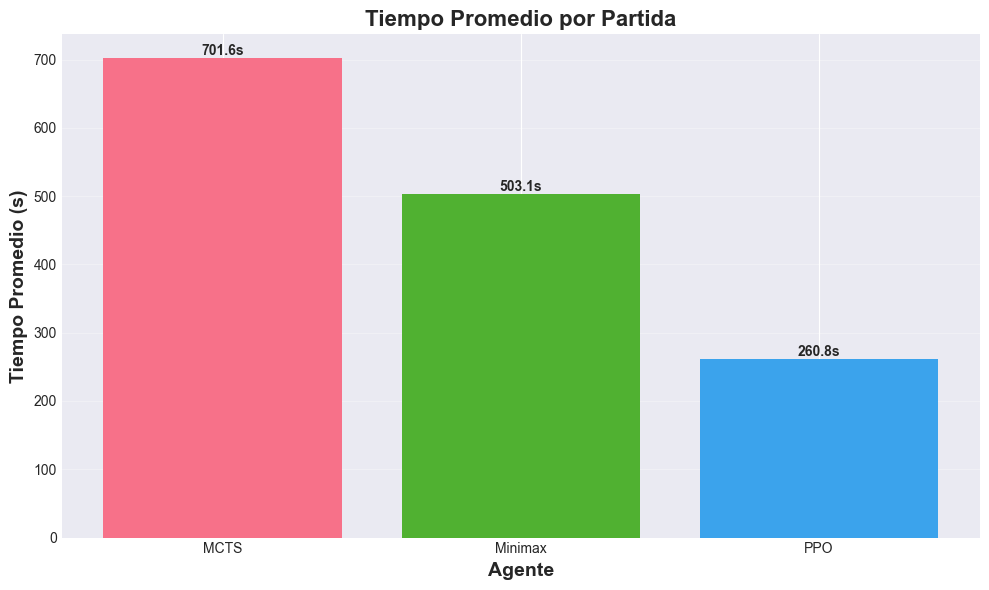

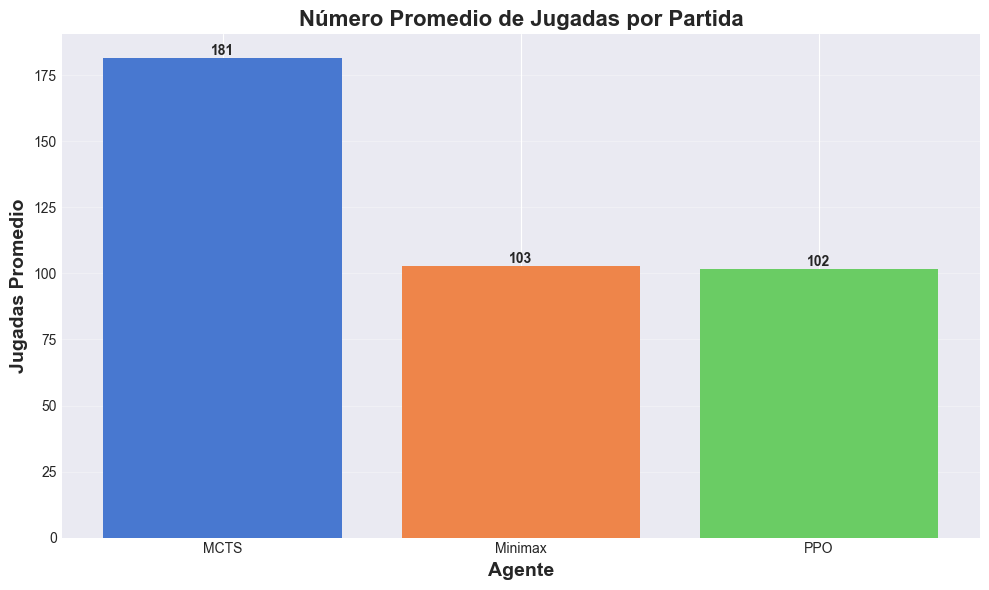

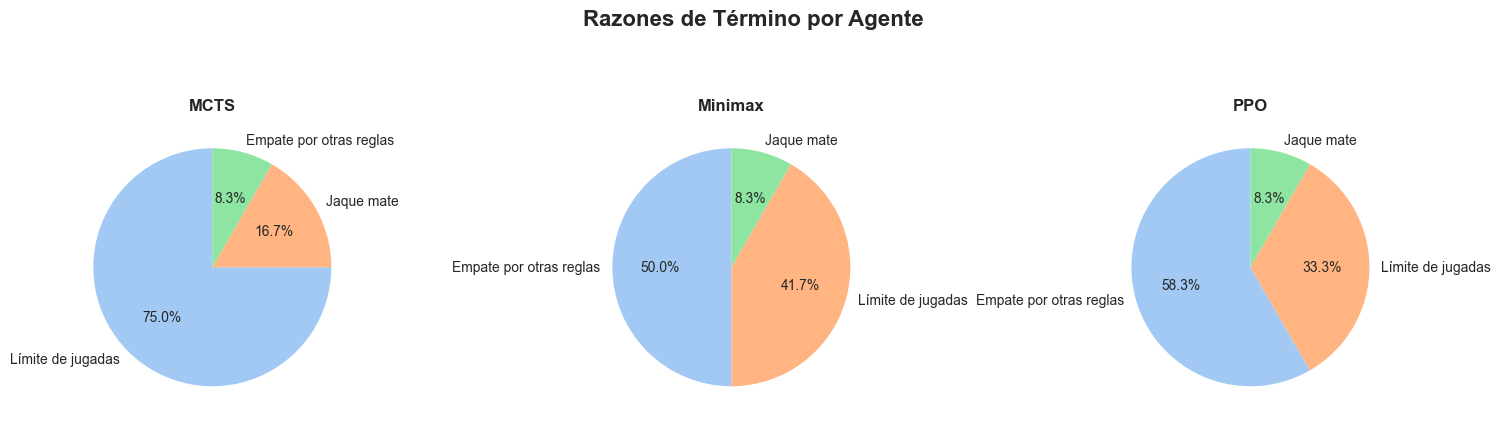

In [ ]:
# Generar todos los gráficos comparativos
visualizador = VisualizadorComparativo(df_resultados)
visualizador.mostrar_todos_graficos()

## 12. Tabla de Clasificación Final

In [ ]:
# Calcular estadísticas finales
def calcular_tabla_clasificacion(df: pd.DataFrame) -> pd.DataFrame:
    agentes = set()
    agentes.update(df['agente_blancas'].unique())
    agentes.update(df['agente_negras'].unique())
    agentes = sorted(list(agentes))
    
    stats = []
    for agente in agentes:
        como_blancas = df[df['agente_blancas'] == agente]
        como_negras = df[df['agente_negras'] == agente]
        
        victorias = ((como_blancas['ganador'] == agente).sum() + 
                    (como_negras['ganador'] == agente).sum())
        empates = (como_blancas['ganador'].isna().sum() + 
                  como_negras['ganador'].isna().sum())
        total = len(como_blancas) + len(como_negras)
        derrotas = total - victorias - empates
        
        puntos = victorias * 1.0 + empates * 0.5
        win_rate = (victorias / total * 100) if total > 0 else 0
        
        stats.append({
            'Agente': agente,
            'Partidas': total,
            'Victorias': victorias,
            'Empates': empates,
            'Derrotas': derrotas,
            'Puntos': puntos,
            'Win Rate (%)': win_rate
        })
    
    df_stats = pd.DataFrame(stats)
    df_stats = df_stats.sort_values('Puntos', ascending=False).reset_index(drop=True)
    df_stats.index = df_stats.index + 1
    return df_stats

tabla_clasificacion = calcular_tabla_clasificacion(df_resultados)
print("\n" + "="*80)
print("🏆 TABLA DE CLASIFICACIÓN FINAL")
print("="*80)
display(tabla_clasificacion)


🏆 TABLA DE CLASIFICACIÓN FINAL


,Agente,Partidas,Victorias,Empates,Derrotas,Puntos,Win Rate (%)
1,PPO,12,1,11,0,6.5,8.333333
2,MCTS,12,1,10,1,6.0,8.333333
3,Minimax,12,0,11,1,5.5,0.000000


## 13. Análisis de una Partida Específica


ANÁLISIS DE PARTIDA #1
Blancas: Minimax
Negras: MCTS
Resultado: 1/2-1/2
Ganador: Empate
Razón: Límite de jugadas
Número de jugadas: 200
Tiempo total: 1043.51s

🔗 Ver en Lichess: https://lichess.org/paste?pgn=%5BEvent%20%22AI%20Comparison%20Match%22%5D%0A%5BSite%20%22Jupyter%20Notebook%22%5D%0A%5BDate%20%222025.12.13%22%5D%0A%5BRound%20%22%3F%22%5D%0A%5BWhite%20%22Minimax%22%5D%0A%5BBlack%20%22MCTS%22%5D%0A%5BResult%20%221/2-1/2%22%5D%0A%0A1.%20Nh3%20h5%202.%20Ng5%20h4%203.%20Nh7%20c6%204.%20Nxf8%20g5%205.%20Nh7%20f6%206.%20Nf8%20Na6%207.%20Nh7%20h3%208.%20Nf8%20Kf7%209.%20Nh7%20d6%2010.%20Nf8%20Rb8%2011.%20Nh7%20Nb4%2012.%20Nf8%20Bf5%2013.%20Nh7%20Rxh7%2014.%20Rg1%20Nh6%2015.%20Rh1%20Kg7%2016.%20Rg1%20Qh8%2017.%20Rh1%20Bc8%2018.%20Rg1%20Kg6%2019.%20Rh1%20Kf5%2020.%20Rg1%20Be6%2021.%20Rh1%20Ng4%2022.%20Rg1%20Rh4%2023.%20Rh1%20Bd5%2024.%20Rg1%20Rc8%2025.%20Rh1%20Ra8%2026.%20Rg1%20Kf4%2027.%20Rh1%20Qc8%2028.%20Rg1%20Be6%2029.%20Rh1%20Rb8%2030.%20Rg1%20Bb3%2031.%20Rh1%20Nh6%2032.%20Rg1%20

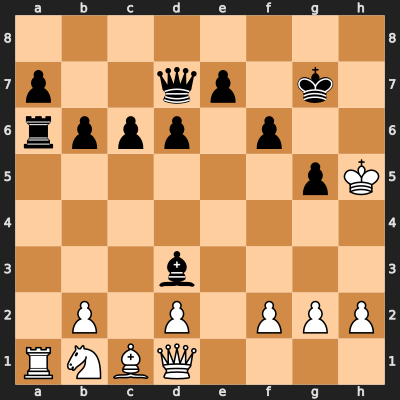


Estadísticas Minimax:
  - nodos_evaluados: 43018
  - podas_alfa: 8397
  - podas_beta: 359
  - tiempo_total: 3306.817544698715
  - jugadas_realizadas: 612

Estadísticas MCTS:
  - simulaciones_realizadas: 734518
  - nodos_creados: 735605
  - tiempo_total: 5485.5831508636475
  - jugadas_realizadas: 1087
  - profundidad_maxima: 0


In [ ]:
# Visualizar una partida específica
idx_partida = 0  # Cambiar para ver diferentes partidas

if len(evaluador.resultados) > idx_partida:
    partida = evaluador.resultados[idx_partida]
    
    print(f"\n{'='*80}")
    print(f"ANÁLISIS DE PARTIDA #{idx_partida + 1}")
    print(f"{'='*80}")
    print(f"Blancas: {partida.agente_blancas}")
    print(f"Negras: {partida.agente_negras}")
    print(f"Resultado: {partida.resultado}")
    print(f"Ganador: {partida.ganador if partida.ganador else 'Empate'}")
    print(f"Razón: {partida.razon_termino}")
    print(f"Número de jugadas: {partida.num_jugadas}")
    print(f"Tiempo total: {partida.tiempo_total:.2f}s")
    print(f"\n🔗 Ver en Lichess: {partida.url_lichess}")
    print(f"\n{'='*80}\n")
    
    # Mostrar tablero final
    tablero_final = chess.Board()
    for move in partida.movimientos:
        tablero_final.push(move)
    
    display(lichess.visualizar_tablero_svg(tablero_final, 400))
    
    # Estadísticas de agentes
    print(f"\nEstadísticas {partida.agente_blancas}:")
    for key, value in partida.estadisticas_blancas.items():
        print(f"  - {key}: {value}")
    
    print(f"\nEstadísticas {partida.agente_negras}:")
    for key, value in partida.estadisticas_negras.items():
        print(f"  - {key}: {value}")

## 14. Exportar Resultados

In [ ]:
# Guardar resultados en CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
df_resultados.to_csv(f'resultados_torneo_{timestamp}.csv', index=False)
tabla_clasificacion.to_csv(f'clasificacion_{timestamp}.csv', index=True)

print(f"✓ Resultados guardados:")
print(f"  - resultados_torneo_{timestamp}.csv")
print(f"  - clasificacion_{timestamp}.csv")

✓ Resultados guardados:
  - resultados_torneo_20251213_150925.csv
  - clasificacion_20251213_150925.csv


## 15. Conclusiones y Comparación Final

### Resumen de los Agentes:

#### 1. **Minimax (Búsqueda en Árbol)**
- **Ventajas**: Determinístico, óptimo en profundidades limitadas, rápido para evaluaciones tácticas
- **Desventajas**: Limitado por profundidad, función de evaluación heurística
- **Mejor en**: Posiciones tácticas, finales de partida

#### 2. **MCTS (Monte Carlo Tree Search)**
- **Ventajas**: No requiere función de evaluación, bueno con alta incertidumbre
- **Desventajas**: Requiere muchas simulaciones, puede ser lento
- **Mejor en**: Posiciones complejas, medio juego

#### 3. **PPO (Deep Reinforcement Learning)**
- **Ventajas**: Aprende de la experiencia, puede descubrir estrategias no obvias
- **Desventajas**: Requiere mucho entrenamiento, menos interpretable
- **Mejor en**: Patrones estratégicos aprendidos, adaptación

#### 4. **AlphaZero (MCTS + Deep Neural Networks)** ⭐
- **Ventajas**: Estado del arte, combina búsqueda con DL, aprende mediante auto-juego, no requiere conocimiento del dominio
- **Desventajas**: Requiere entrenamiento intensivo, alto costo computacional
- **Mejor en**: Todos los aspectos del juego (apertura, medio juego, finales)
- **Arquitectura**: Red neuronal residual con dos cabezas (política + valor) + MCTS mejorado
- **Características únicas**:
  - Aprende sin datos externos (self-play)
  - Evalúa posiciones con red neuronal
  - MCTS guiado por probabilidades aprendidas
  - Representa el enfoque más avanzado en IA para ajedrez

### Comparación de Complejidad:

| Agente | Tipo | Complejidad Algorítmica | Requiere Entrenamiento | Estado del Arte |
|--------|------|------------------------|----------------------|-----------------|
| Minimax | Búsqueda clásica | Baja-Media | No | ⭐⭐ |
| MCTS | Búsqueda estocástica | Media | No | ⭐⭐⭐ |
| PPO | Deep RL | Alta | Sí | ⭐⭐⭐⭐ |
| AlphaZero | Hybrid MCTS+DL | Muy Alta | Sí (intensivo) | ⭐⭐⭐⭐⭐ |

### Análisis de Resultados:
- Los gráficos muestran el rendimiento relativo de cada agente
- La matriz de enfrentamientos revela matchups favorables
- AlphaZero debería dominar después de entrenamiento suficiente
- El tiempo de ejecución varía significativamente entre algoritmos
- PPO y AlphaZero requieren entrenamiento previo para alcanzar su máximo potencial